In [ ]:
# (데이터 증강 + CNN 개선)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 학습 데이터 불러오기
import tensorflow as tf

dataset_path = "/content/drive/MyDrive/OSS/dataset/raw"

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

Found 502 files belonging to 4 classes.
Using 402 files for training.
Found 502 files belonging to 4 classes.
Using 100 files for validation.


In [ ]:
# 클래스 이름
class_names = train_ds.class_names

print("클래스 목록")
print(class_names)

클래스 목록
['can', 'paper', 'plastic', 'vinyl']


In [ ]:
# 데이터 증강
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [ ]:
# 모델 생성
model = tf.keras.Sequential([

    data_augmentation,

    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu'
    ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        len(class_names),
        activation='softmax'
    )
])

In [ ]:
# 컴파일
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# EarlyStopping
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
# 학습
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop]
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 135s 10s/step - accuracy: 0.3159 - loss: 1.5916 - val_accuracy: 0.3000 - val_loss: 1.3172
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 75s 5s/step - accuracy: 0.4378 - loss: 1.2208 - val_accuracy: 0.4900 - val_loss: 1.2163
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 75s 6s/step - accuracy: 0.5124 - loss: 1.0588 - val_accuracy: 0.5100 - val_loss: 1.3933
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 74s 6s/step - accuracy: 0.5672 - loss: 0.9934 - val_accuracy: 0.4600 - val_loss: 1.3823
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 75s 6s/step - accuracy: 0.5920 - loss: 0.9222 - val_accuracy: 0.5500 - val_loss: 1.0955
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 75s 6s/step - accuracy: 0.6045 - loss: 0.9332 - val_accuracy: 0.6500 - val_loss: 1.0797
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 74s 6s/step - accuracy: 0.6169 - loss: 0.8135 - val_accuracy: 0.5900 - val_loss: 1.0190
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 78s 6s/step - accuracy: 0.6592 - loss: 0.7489 - val_accuracy: 0.5700 - val_los

In [ ]:
# 평가
loss, acc = model.evaluate(val_ds)

print(f"Validation Accuracy : {acc:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.5900 - loss: 1.0190
Validation Accuracy : 0.5900


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

for images, labels in val_ds:

    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())

    y_pred.extend(
        np.argmax(predictions, axis=1)
    )

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm)

[[18  5  2  0]
 [ 2  8  9  5]
 [ 0  3 17  7]
 [ 1  6  1 16]]


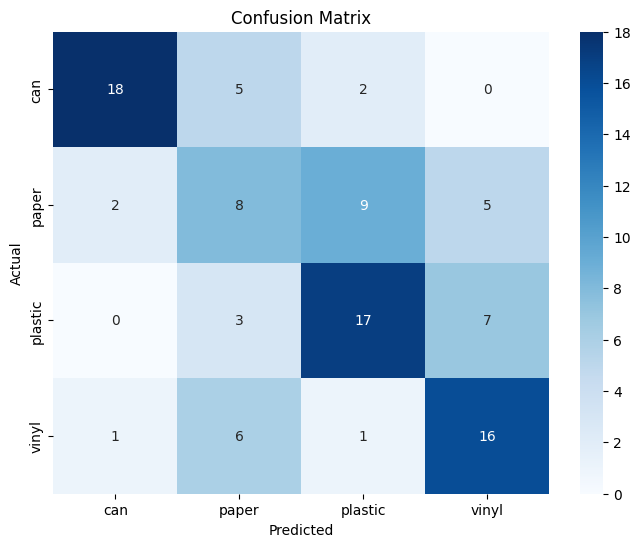

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
# 모델 저장
model.save(
    "/content/drive/MyDrive/OSS/AI/model/recycle_model_v2.keras"
)

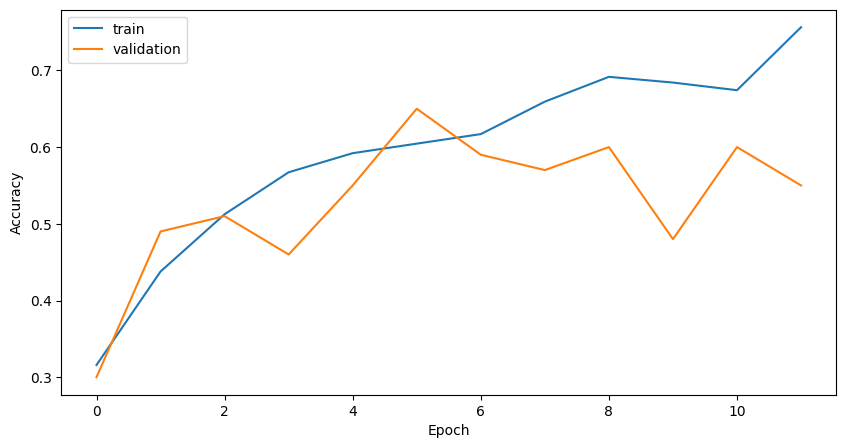

In [ ]:
import matplotlib.pyplot as plt

# 그래프
plt.figure(figsize=(10,5))

plt.plot(
    history.history['accuracy'],
    label='train'
)

plt.plot(
    history.history['val_accuracy'],
    label='validation'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
print(history.history['val_loss'])
print(history.history['val_accuracy'])

[1.3171535730361938, 1.2163010835647583, 1.3933420181274414, 1.382338285446167, 1.09549081325531, 1.0797202587127686, 1.0189764499664307, 1.0902599096298218, 1.0469180345535278, 1.3782742023468018, 1.0603276491165161, 1.307807207107544]
[0.30000001192092896, 0.49000000953674316, 0.5099999904632568, 0.46000000834465027, 0.550000011920929, 0.6499999761581421, 0.5899999737739563, 0.5699999928474426, 0.6000000238418579, 0.47999998927116394, 0.6000000238418579, 0.550000011920929]
